In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/lsind18/tarot-json/tarot-images.json
/kaggle/input/datasets/lsind18/tarot-json/cards/w05.jpg
/kaggle/input/datasets/lsind18/tarot-json/cards/w11.jpg
/kaggle/input/datasets/lsind18/tarot-json/cards/p04.jpg
/kaggle/input/datasets/lsind18/tarot-json/cards/p08.jpg
/kaggle/input/datasets/lsind18/tarot-json/cards/s07.jpg
/kaggle/input/datasets/lsind18/tarot-json/cards/c01.jpg
/kaggle/input/datasets/lsind18/tarot-json/cards/m09.jpg
/kaggle/input/datasets/lsind18/tarot-json/cards/m21.jpg
/kaggle/input/datasets/lsind18/tarot-json/cards/s14.jpg
/kaggle/input/datasets/lsind18/tarot-json/cards/c12.jpg
/kaggle/input/datasets/lsind18/tarot-json/cards/c14.jpg
/kaggle/input/datasets/lsind18/tarot-json/cards/p02.jpg
/kaggle/input/datasets/lsind18/tarot-json/cards/s12.jpg
/kaggle/input/datasets/lsind18/tarot-json/cards/w04.jpg
/kaggle/input/datasets/lsind18/tarot-json/cards/m03.jpg
/kaggle/input/datasets/lsind18/tarot-json/cards/m08.jpg
/kaggle/input/datasets/lsind18/tarot-json/ca

In [2]:
import os
import json
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

plt.style.use("ggplot")

In [3]:
#explore dataset
for root, dirs, files in os.walk("/kaggle/input"):
    print(root)

    for file in files:
        print("   ", file)

/kaggle/input
/kaggle/input/datasets
/kaggle/input/datasets/lsind18
/kaggle/input/datasets/lsind18/tarot-json
    tarot-images.json
/kaggle/input/datasets/lsind18/tarot-json/cards
    w05.jpg
    w11.jpg
    p04.jpg
    p08.jpg
    s07.jpg
    c01.jpg
    m09.jpg
    m21.jpg
    s14.jpg
    c12.jpg
    c14.jpg
    p02.jpg
    s12.jpg
    w04.jpg
    m03.jpg
    m08.jpg
    m20.jpg
    c08.jpg
    p05.jpg
    w10.jpg
    m06.jpg
    c11.jpg
    p01.jpg
    c02.jpg
    w03.jpg
    m02.jpg
    s02.jpg
    c04.jpg
    m19.jpg
    m12.jpg
    p11.jpg
    m10.jpg
    s09.jpg
    m15.jpg
    p10.jpg
    m14.jpg
    s04.jpg
    c03.jpg
    m11.jpg
    w02.jpg
    c05.jpg
    c09.jpg
    w14.jpg
    s01.jpg
    s05.jpg
    p09.jpg
    m04.jpg
    w12.jpg
    w01.jpg
    s06.jpg
    c07.jpg
    c13.jpg
    p06.jpg
    w09.jpg
    m17.jpg
    s08.jpg
    m18.jpg
    p07.jpg
    m01.jpg
    s10.jpg
    m13.jpg
    w06.jpg
    p13.jpg
    p03.jpg
    m05.jpg
    w08.jpg
    w07.jpg
    s11.jpg
    

In [4]:
json_file = None

for root, dirs, files in os.walk("/kaggle/input"):
    for file in files:
        if file.endswith(".json"):
            json_file = os.path.join(root, file)
            print("Found JSON:", json_file)
            break

if json_file is None:
    raise FileNotFoundError("No JSON file found!")

Found JSON: /kaggle/input/datasets/lsind18/tarot-json/tarot-images.json


In [5]:
json_path = None

for root, dirs, files in os.walk("/kaggle/input"):
    for file in files:
        if file.endswith(".json"):
            json_path = os.path.join(root,file)
            break

print(json_path)

/kaggle/input/datasets/lsind18/tarot-json/tarot-images.json


In [6]:
#Load json
with open(json_path,"r",encoding="utf-8") as f:
    tarot=json.load(f)

In [7]:
#inspect the json structure
print(type(tarot))

<class 'dict'>


In [8]:
#Explore JSON Structure
print(tarot.keys())
#If dictionary
print(tarot.keys())

dict_keys(['description', 'cards'])
dict_keys(['description', 'cards'])


In [9]:
#convert to dataframe
if isinstance(tarot,dict):

    if "cards" in tarot:

        df=pd.DataFrame(tarot["cards"])

    else:

        df=pd.DataFrame(tarot)

else:

    df=pd.DataFrame(tarot)

In [10]:
#Dataset Overview
print("Rows :",len(df))

print("Columns :",len(df.columns))

df.head()

Rows : 78
Columns : 16


,name,number,arcana,suit,img,fortune_telling,keywords,meanings,Archetype,Hebrew Alphabet,Numerology,Elemental,Mythical/Spiritual,Questions to Ask,Astrology,Affirmation
0,The Fool,0,Major Arcana,Trump,m00.jpg,"[Watch for new projects and new beginnings, Pr...","[freedom, faith, inexperience, innocence]","{'light': ['Freeing yourself from limitation',...",The Divine Madman,Aleph/Ox/1,0 (off the scale; pure potential),Air,Adam before the fall. Christ as a wandering ho...,[What would I do if I felt free to take a leap...,NaN,NaN
1,The Magician,1,Major Arcana,Trump,m01.jpg,"[A powerful man may play a role in your day, Y...","[capability, empowerment, activity]","{'light': ['Taking appropriate action', 'Recei...",The Ego/The Self,Beth/House/2,"1 (origins, unity, seeds)",The Sun/Mercury,"Thoth, the Egyptian god of wisdom, known to th...","[What am I empowered to do?, How might my abil...",NaN,NaN
2,The High Priestess,2,Major Arcana,Trump,m02.jpg,"[A mysterious woman arrives, A sexual secret m...","[intuition, reflection, purity, initiation]",{'light': ['Listening to your feelings and int...,The Virgin/The Maiden,Gimel/Camel/3,"2 (division, debate, duality)",The Moon,"The feminine aspect of divinity, particularity...","[What might a rebel against tradition do?, Wha...",NaN,NaN
3,The Empress,3,Major Arcana,Trump,m03.jpg,"[Pregnancy is in the cards, An opportunity to ...","[fertility, productivity, ripeness, nurturing]","{'light': ['Nurturing yourself and others', 'B...",The Mother,Daleth/Door/4,"3 (expression, productivity, output)",Venus,"Gaia, Mother Earth, Ishtar, DemeterÑmature, re...",[What would a concerned and capable mother do?...,NaN,NaN
4,The Emperor,4,Major Arcana,Trump,m04.jpg,"[A father figure arrives, A new employer or au...","[authority, regulation, direction, structure]","{'light': ['Exercising authority', 'Defining l...",The Father,"He[as]/Window/5, or in some decks, Tzaddi/Fish...","4 (stability, equality, persistence)",Mars/Aries,"Masculine gods, including the Hebrew God, the ...",[How does the issue of control or regulation i...,NaN,NaN


In [11]:
#Dataset Information
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 78 entries, 0 to 77
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   name                78 non-null     object
 1   number              78 non-null     object
 2   arcana              78 non-null     object
 3   suit                78 non-null     object
 4   img                 78 non-null     object
 5   fortune_telling     78 non-null     object
 6   keywords            78 non-null     object
 7   meanings            78 non-null     object
 8   Archetype           22 non-null     object
 9   Hebrew Alphabet     22 non-null     object
 10  Numerology          62 non-null     object
 11  Elemental           38 non-null     object
 12  Mythical/Spiritual  22 non-null     object
 13  Questions to Ask    78 non-null     object
 14  Astrology           40 non-null     object
 15  Affirmation         56 non-null     object
dtypes: object(16)
memory usage: 

In [12]:
#column names
print(df.columns.tolist())

['name', 'number', 'arcana', 'suit', 'img', 'fortune_telling', 'keywords', 'meanings', 'Archetype', 'Hebrew Alphabet', 'Numerology', 'Elemental', 'Mythical/Spiritual', 'Questions to Ask', 'Astrology', 'Affirmation']


In [13]:
#Missing Values
missing=df.isnull().sum()

missing

name                   0
number                 0
arcana                 0
suit                   0
img                    0
fortune_telling        0
keywords               0
meanings               0
Archetype             56
Hebrew Alphabet       56
Numerology            16
Elemental             40
Mythical/Spiritual    56
Questions to Ask       0
Astrology             38
Affirmation           22
dtype: int64

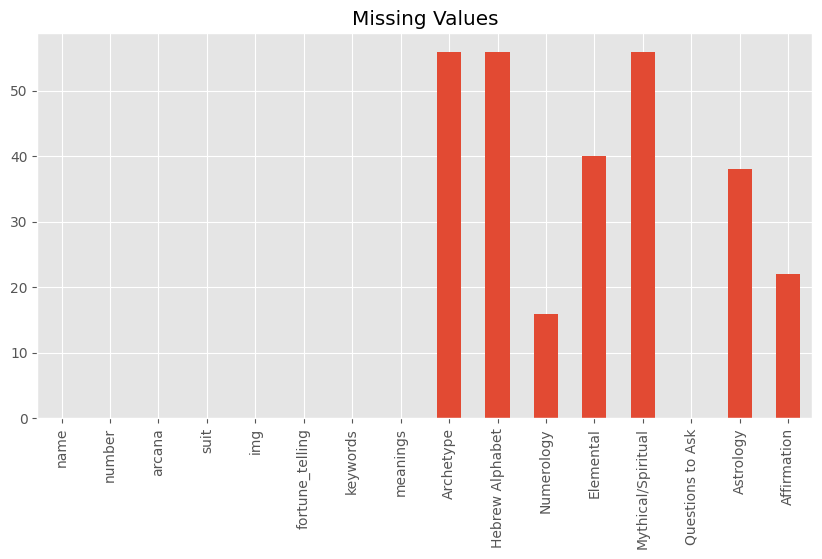

In [14]:
#plot|
plt.figure(figsize=(10,5))

missing.plot(kind="bar")

plt.title("Missing Values")

plt.show()

In [15]:
#Data Types
dtype=pd.DataFrame({

"Column":df.columns,

"Datatype":df.dtypes

})

dtype

,Column,Datatype
name,name,object
number,number,object
arcana,arcana,object
suit,suit,object
img,img,object
fortune_telling,fortune_telling,object
keywords,keywords,object
meanings,meanings,object
Archetype,Archetype,object
Hebrew Alphabet,Hebrew Alphabet,object


In [16]:
#Count Total Cards
print("Total Tarot Cards :",len(df))

Total Tarot Cards : 78


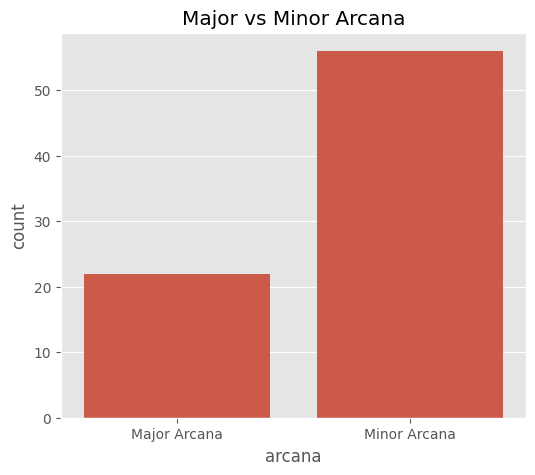

In [17]:
#Check Arcana Distribution
if "arcana" in df.columns:

    plt.figure(figsize=(6,5))

    sns.countplot(data=df,x="arcana")

    plt.title("Major vs Minor Arcana")

    plt.show()

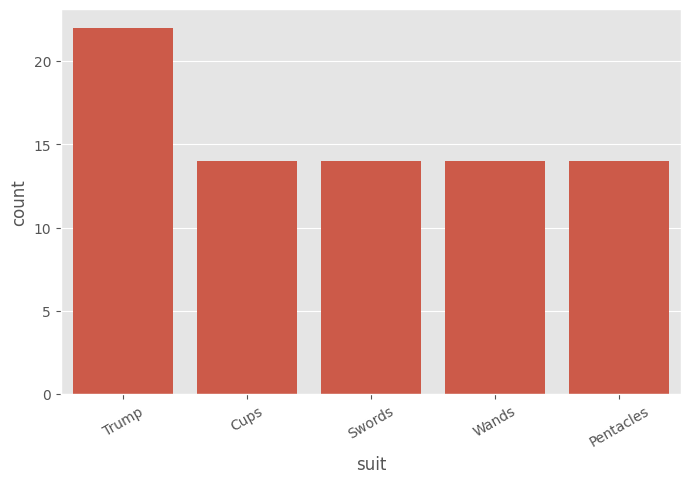

In [18]:
#Suit Distribution
if "suit" in df.columns:

    plt.figure(figsize=(8,5))

    sns.countplot(

        data=df,

        x="suit",

        order=df["suit"].value_counts().index

    )

    plt.xticks(rotation=30)

    plt.show()

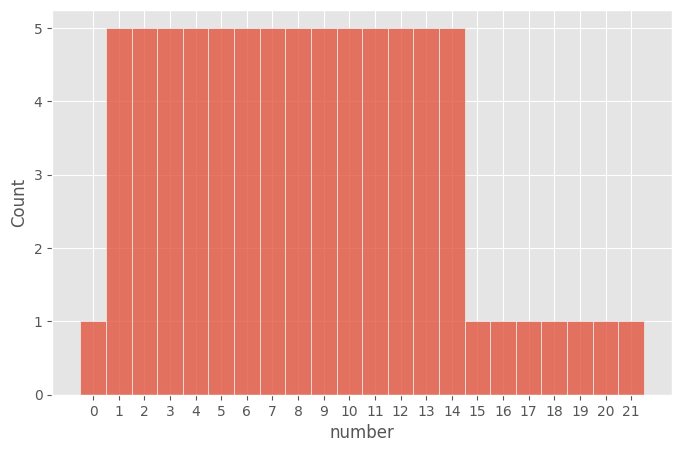

In [19]:
#Card Number Distribution
if "number" in df.columns:

    plt.figure(figsize=(8,5))

    sns.histplot(df["number"])

    plt.show()

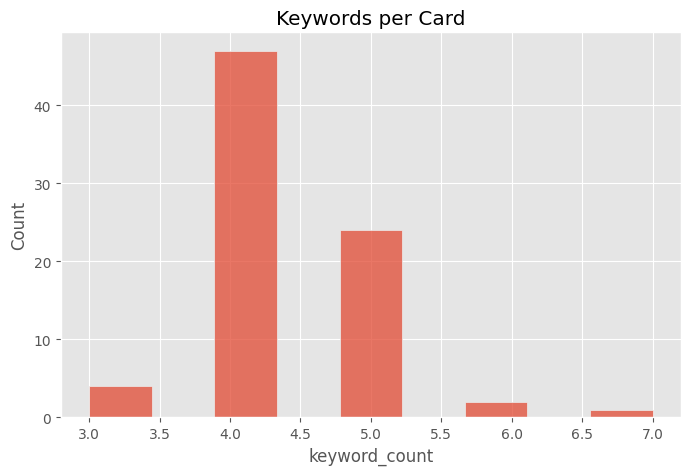

In [20]:
#Keyword Count
if "keywords" in df.columns:

    df["keyword_count"]=df["keywords"].apply(

        lambda x:len(x) if isinstance(x,list) else 0

    )

    plt.figure(figsize=(8,5))

    sns.histplot(df["keyword_count"])

    plt.title("Keywords per Card")

    plt.show()

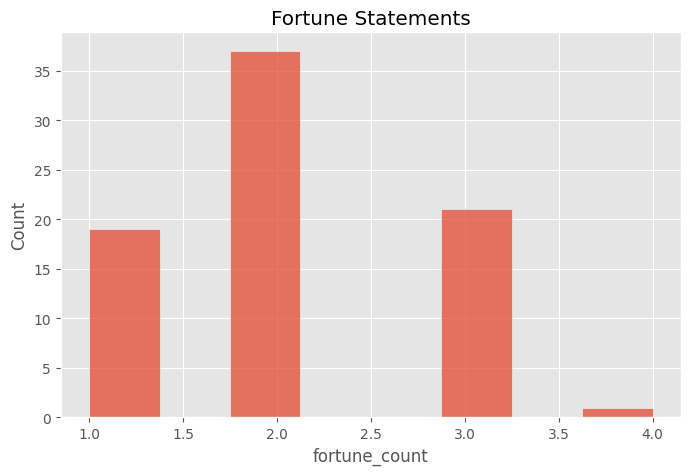

In [21]:
#Fortune Telling Count
if "fortune_telling" in df.columns:

    df["fortune_count"]=df["fortune_telling"].apply(

        lambda x:len(x) if isinstance(x,list) else 0

    )

    plt.figure(figsize=(8,5))

    sns.histplot(df["fortune_count"])

    plt.title("Fortune Statements")

    plt.show()

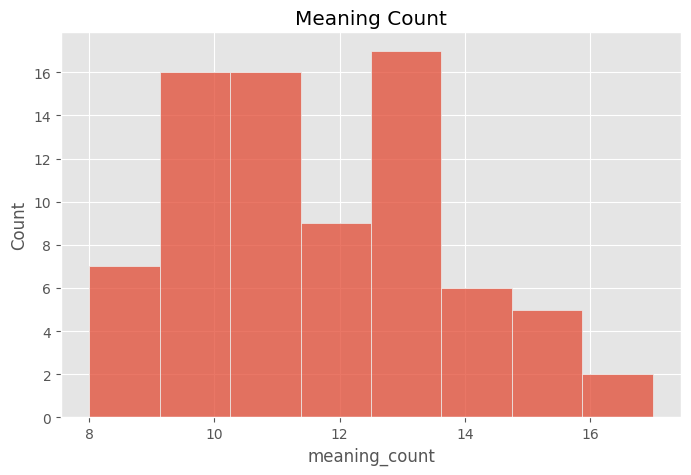

In [22]:
#Meaning Count
if "meanings" in df.columns:

    def count_meanings(x):

        if isinstance(x,dict):

            total=0

            for value in x.values():

                total+=len(value)

            return total

        return 0

    df["meaning_count"]=df["meanings"].apply(count_meanings)

    plt.figure(figsize=(8,5))

    sns.histplot(df["meaning_count"])

    plt.title("Meaning Count")

    plt.show()

In [23]:
#Questions Count
if "Questions to Ask" in df.columns:

    df["question_count"]=df["Questions to Ask"].apply(

        lambda x:len(x) if isinstance(x,list) else 0

    )

In [24]:
#Random Tarot Cards
df.sample(10)

,name,number,arcana,suit,img,fortune_telling,keywords,meanings,Archetype,Hebrew Alphabet,Numerology,Elemental,Mythical/Spiritual,Questions to Ask,Astrology,Affirmation,keyword_count,fortune_count,meaning_count,question_count
44,Nine of Swords,9,Minor Arcana,Swords,s09.jpg,[If you take the action you're considering now...,"[remorse, worry, distraught, conclusion]",{'light': ['Refusing to worry about what you c...,NaN,NaN,"9 (The Completion: fullness, readiness, ripeness)",NaN,NaN,[What role does worry play in your current sit...,Mars in Gemini,"""I do not worry about what I cannot control.""",4,1,14,3
77,King of Pentacles,14,Minor Arcana,Pentacles,p14.jpg,[This card represents an older man with a fina...,"[stability, dependability, confidence, interve...","{'light': ['Becoming debt-free', 'Having more ...",NaN,NaN,NaN,Fire of Earth.,NaN,[How can you handle expenses with greater conf...,NaN,"""I embody confidence and fairness.""",4,1,13,3
28,Seven of Cups,7,Minor Arcana,Cups,c07.jpg,"[You're being fed a line, Rather than be dazzl...","[imagination, dreams, illusions, goals]",{'light': ['Motivating yourself with images of...,NaN,NaN,"7 (The Motive: imagination, inner work, psycho...",NaN,NaN,[What do you want most? What do you fear most?...,Venus in Scorpio,"""I use inner vision as a tool for growth.""",4,2,10,3
75,Knight of Pentacles,12,Minor Arcana,Pentacles,p12.jpg,[A stingy person may chide you for spending mo...,"[caution, focus, realism, invention]","{'light': ['Spending money wisely', 'Saving fo...",NaN,NaN,NaN,Air of Earth.,NaN,[What's the difference between caution and fea...,NaN,"""I temper my actions with cautious optimism.""",4,2,15,3
70,Seven of Pentacles,7,Minor Arcana,Pentacles,p07.jpg,"[Things won't work out as expected, Pick up th...","[assessment, evaluation, re-evaluation, reflec...",{'light': ['Measuring progress toward your goa...,NaN,NaN,"7 (The Motive: imagination, inner work, psycho...",NaN,NaN,[To what extent have I fulfilled my own expect...,Saturn in Taurus,"""To stay on target, I measure my progress.""",4,2,12,3
11,Justice,11,Major Arcana,Trump,m11.jpg,"[A legal verdict will be rendered soon, Someon...","[balance, law, fairness, objectivity]","{'light': ['Making an objective decision', 'We...",The Id,Theth/Snake/9 or Lamed/Outstretched Arms/30,"11 = 1 + 1 = 2 (debate, duality) or 8 (movemen...",Leo or Libra,Samson. Hercules. Daniel in the lion's den. Th...,"[How can I enhance my self-discipline?, What b...",NaN,NaN,4,3,11,3
49,King of Swords,14,Minor Arcana,Swords,s14.jpg,[This card represents an older man with an ins...,"[genius, expertise, decision, verdict]",{'light': ['Expressing yourself with firmness ...,NaN,NaN,NaN,Fire of Air.,NaN,[What would your decision be if you had to ren...,NaN,"""My word is my bond.""",4,1,13,3
52,Three of Wands,3,Minor Arcana,Wands,w03.jpg,"[You'll be planning a trip soon, Be on the loo...","[implementation, action, exploration]","{'light': ['Putting a plan into motion', 'Taki...",NaN,NaN,"3 (The Result: expression, productivity, output)",NaN,NaN,[How can you make a habit of breaking your hab...,Sun in Aries,"""I take the steps necessary to put my plans in...",3,2,12,3
41,Six of Swords,6,Minor Arcana,Swords,s06.jpg,"[You'll soon go on a long journey over water, ...","[adaptation, adjustments, science, travel]",{'light': ['Making the best of a bad situation...,NaN,NaN,"6 (The Adjustment: cooperation, collaboration,...",NaN,NaN,"[What assumptions govern my thinking?, How wil...",Mercury in Aquarius,"""I keep an open mind.""",4,2,12,3
42,Seven of Swords,7,Minor Arcana,Swords,s07.jpg,[Don't assume people around you are worthy of ...,"[dishonesty, presumption, sneakiness, assumpti...",{'light': ['Refusing to do something dishonest...,NaN,NaN,"7 (The Motive: imagination, inner work, psycho...",NaN,NaN,"[What assumptions am I making?, How well-defin...",Moon in Aquarius,"""I hold myself to the highest ethical standards.""",4,2,10,3


78


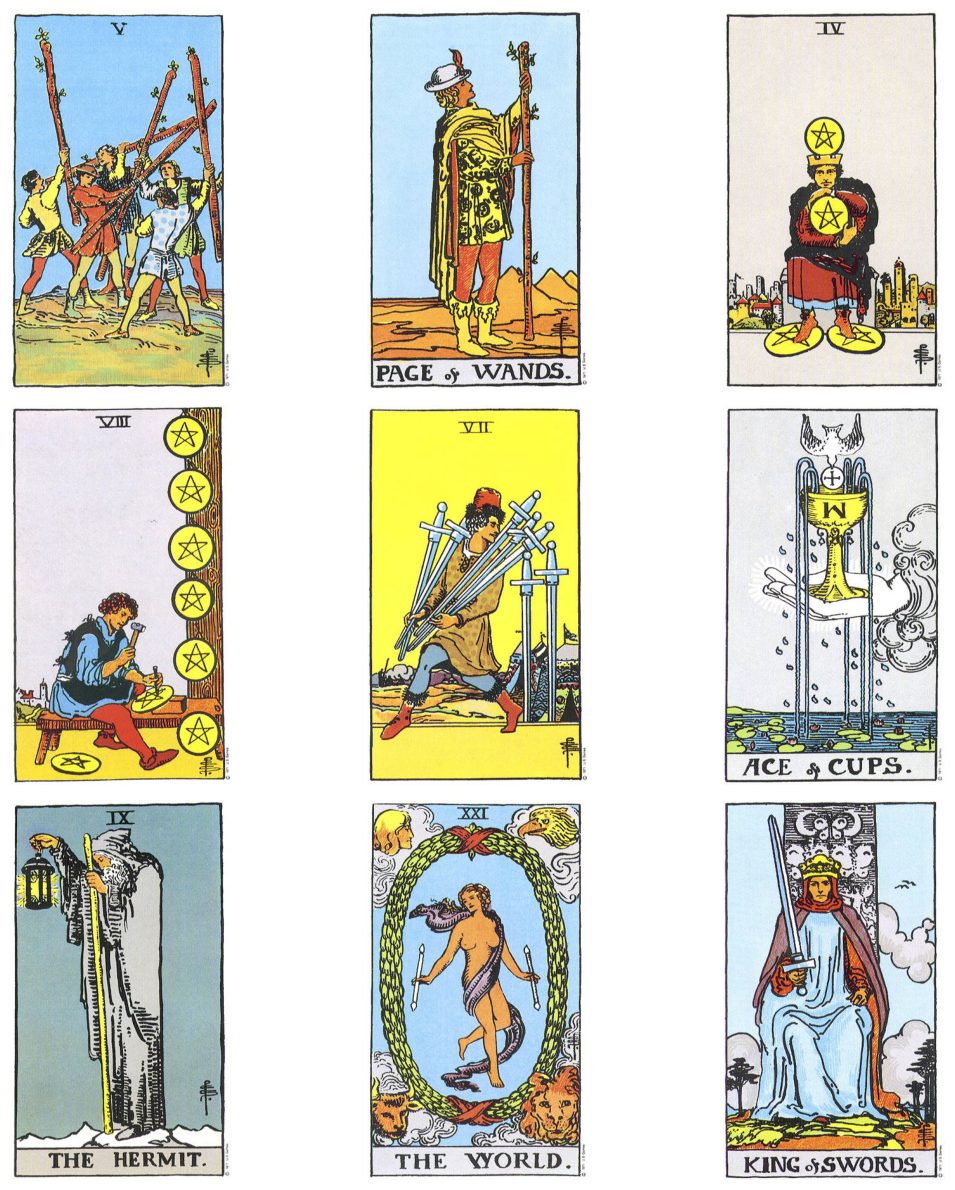

In [25]:
#Display Card Images
image_files=[]

for root,dirs,files in os.walk("/kaggle/input"):

    for file in files:

        if file.endswith((".jpg",".png",".jpeg")):

            image_files.append(os.path.join(root,file))

print(len(image_files))

#Display
plt.figure(figsize=(12,12))

sample=image_files[:9]

for i,path in enumerate(sample):

    img=Image.open(path)

    plt.subplot(3,3,i+1)

    plt.imshow(img)

    plt.axis("off")

plt.tight_layout()

plt.show()

In [26]:
#JSON Statistics
summary=pd.DataFrame({

"Column":df.columns,

"Missing":df.isnull().sum(),

"Datatype":df.dtypes

})

summary

,Column,Missing,Datatype
name,name,0,object
number,number,0,object
arcana,arcana,0,object
suit,suit,0,object
img,img,0,object
fortune_telling,fortune_telling,0,object
keywords,keywords,0,object
meanings,meanings,0,object
Archetype,Archetype,56,object
Hebrew Alphabet,Hebrew Alphabet,56,object


In [27]:
#Random Card Details
card=df.sample(1).iloc[0]

for col in df.columns:

    print("="*40)

    print(col)

    print(card[col])

name
Queen of Cups
number
13
arcana
Minor Arcana
suit
Cups
img
c13.jpg
fortune_telling
['This card represents a woman with an emotional, deeply spiritual nature, likely born between June 11th and July 11th, who uses emotional and spiritual appeals to sway others to her point of view']
keywords
['insightfulness', 'spirituality', 'compassion', 'empathy', 'instinct']
meanings
{'light': ['Allowing yourself to be moved by the plight of others', 'Feeling strong emotions', 'Possessing unusual sympathy or empathy', 'Trusting your feelings to guide you', 'Calling on psychic abilities', 'Achieving unity with Spirit'], 'shadow': ['Becoming so caught up in matters of Spirit, you become detached from the world', 'Allowing empathy to disable you (instead of inspire action)', 'Using psychic abilities to wield covert influence', 'Wallowing in emotionalism, sentiment, or self-pity']}
Archetype
nan
Hebrew Alphabet
nan
Numerology
nan
Elemental
Water of Water.
Mythical/Spiritual
nan
Questions to Ask
['How

In [28]:
#Final EDA Summary
print("Total Cards :",len(df))

print("Columns :",len(df.columns))

print("Missing Values :",df.isnull().sum().sum())

Total Cards : 78
Columns : 20
Missing Values : 284
